# Import Essential Packages

In [58]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler


# Neural Network with PyTorch 1

## Loading Dataset

In [129]:
df = pd.read_csv('../../data/Iris Dataset/Iris.csv')
df.head(3)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa


In [130]:
df = df.drop(columns = ['Id'])

encoder = OrdinalEncoder()

df['Species'] = encoder.fit_transform(df[['Species']])


In [131]:
X = df.drop("Species", axis = 1)
y = df['Species']

In [132]:
X = X.values
y = y.values

## Train, Test, Split

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2, 
                                                    random_state = 41)

In [134]:
# Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [135]:
# Convert y labels to tensors long

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

## Model Creation

In [136]:
# Create a Model Class that inherits nn.Module

class Model(nn.Module):
    # Input Layer (4 features of the flower) ==> 
    # H1 (no. of neurons) ==> 
    # H2 (n) ==> 
    # Output 

    def __init__(self, in_features = 4, h1 = 8, h2 = 8, out_features = 3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x


In [137]:
# Picking a seed
torch.manual_seed(41)

#Create instance of Model

model = Model()

In [138]:
# Set Criterion of model to measure the error

criterion = nn.CrossEntropyLoss()

# Choose Optimizer => Adam, lr => learning rate

optimizer =  torch.optim.Adam(model.parameters(), lr = 0.01)


## Model Training and Evaluation

In [140]:
# Train Model

epochs = 100
losses = []

for i in range(epochs):
    y_pred = model.forward(X_train) 

    loss = criterion(y_pred, y_train)

    losses.append(loss.detach().numpy())

    if i % 10 == 0:
        print(f"Epoch: {i}, Loss: {loss}")

    # Back Propagation

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



Epoch: 0, Loss: 1.1318050622940063
Epoch: 10, Loss: 0.9658581614494324
Epoch: 20, Loss: 0.67915278673172
Epoch: 30, Loss: 0.40087205171585083
Epoch: 40, Loss: 0.22570067644119263
Epoch: 50, Loss: 0.12255845218896866
Epoch: 60, Loss: 0.07509137690067291
Epoch: 70, Loss: 0.05467578023672104
Epoch: 80, Loss: 0.04448389261960983
Epoch: 90, Loss: 0.03846167400479317


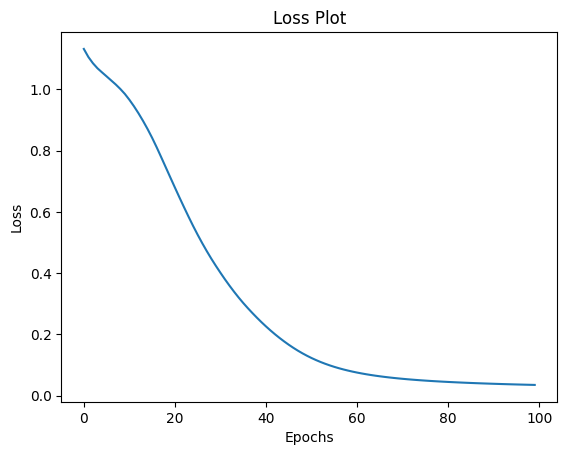

In [141]:
plt.title("Loss Plot")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(losses)

plt.show()

In [142]:
with torch.no_grad(): #turns off back prop
    y_eval = model.forward(X_test)
    loss = criterion(y_eval, y_test)


In [143]:
correct = 0

with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        print(f"{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}")


        if y_val.argmax().item() == y_test[i]:
            correct += 1
        
print("Correct: ", correct)

1.) tensor([-7.7132,  1.5807,  4.8588]) 	 2 	 2
2.) tensor([-10.2249,   0.5155,   8.7638]) 	 2 	 2
3.) tensor([-10.7185,   1.1882,   8.2269]) 	 2 	 2
4.) tensor([-4.4690,  3.5339, -1.1210]) 	 1 	 1
5.) tensor([-9.0873,  1.4669,  6.2793]) 	 2 	 2
6.) tensor([-2.2770,  3.7022, -4.1140]) 	 1 	 1
7.) tensor([-7.0673,  2.2028,  3.2917]) 	 2 	 2
8.) tensor([-4.2226,  3.6468, -1.5420]) 	 1 	 1
9.) tensor([-8.0634,  1.8251,  4.7820]) 	 2 	 2
10.) tensor([-10.8515,   0.5058,   9.3629]) 	 2 	 2
11.) tensor([-6.8611,  2.2126,  3.0811]) 	 2 	 2
12.) tensor([  9.4301,   3.2669, -18.8494]) 	 0 	 0
13.) tensor([  8.5966,   2.9338, -17.1305]) 	 0 	 0
14.) tensor([-1.0571,  3.1664, -4.7063]) 	 1 	 1
15.) tensor([  8.0257,   3.2469, -16.7651]) 	 0 	 0
16.) tensor([-6.7032,  2.4148,  2.6586]) 	 2 	 2
17.) tensor([  8.4607,   3.0915, -17.1118]) 	 0 	 0
18.) tensor([-7.5983,  1.7014,  4.5610]) 	 1 	 2
19.) tensor([  9.0443,   3.1470, -18.0944]) 	 0 	 0
20.) tensor([  7.7209,   2.9005, -15.7171]) 	 0 	 0
21

In [144]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.0])

In [154]:
with torch.no_grad():
    print(model(new_iris).argmax())

tensor(0)


## Saving and Loading Neural Network Pytorch

In [ ]:
# Save Model
torch.save(model.state_dict(), 'iris_model.pt')

In [156]:
# Load Model

new_model = Model()
new_model.load_state_dict(torch.load('../../models/pytorch/iris_model.pt'))

<All keys matched successfully>

In [159]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)

In [161]:
with torch.no_grad():
    print(model(new_iris))

tensor([  9.5577,   3.1315, -18.8803])


# Neural Network with Pytorch 2

## Tensors

In [22]:
arr = np.array([[1, 2, 3], [5, 6, 7]])
arr

array([[1, 2, 3],
       [5, 6, 7]])

In [23]:
tensor = torch.Tensor([[1, 2, 3], [5, 6, 7]])
tensor

tensor([[1., 2., 3.],
        [5., 6., 7.]])

In [ ]:
# arr.sum()
tensor.sum()

tensor(24.)

In [27]:
tensor = torch.from_numpy(arr)
tensor

tensor([[1, 2, 3],
        [5, 6, 7]])

In [29]:
np.ones((2, 4))

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [30]:
torch.ones((2, 9))

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [31]:
np.random.random((2, 4))

array([[0.74788402, 0.10975433, 0.8143166 , 0.15665781],
       [0.92003984, 0.61440715, 0.21897914, 0.98610246]])

In [32]:
torch.rand((2, 4))

tensor([[0.3746, 0.6680, 0.8771, 0.1625],
        [0.1306, 0.7978, 0.3591, 0.1620]])

In [39]:
print(arr.dtype)
print(arr.device)
print(arr.shape)

int64
cpu
(2, 3)


In [40]:
print(tensor.dtype)
print(tensor.device)
print(tensor.shape)

torch.int64
cpu
torch.Size([2, 3])


In [45]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# model = myModel().to(device) #if there's a model

print(device)

cpu


## Automatic Differentiation

In [51]:
a = torch.tensor([2., 3.], requires_grad = True)
b = torch.tensor([6., 4.], requires_grad = True)

f = 3 * a ** 3 - b ** 2


In [52]:
f

tensor([-12.,  65.], grad_fn=<SubBackward0>)

In [53]:
f.backward(gradient = torch.tensor([1, 1]))

In [55]:
print(a.grad)
print(b.grad)

tensor([36., 81.])
tensor([-12.,  -8.])


## Loading Dataset

In [124]:
X, y = load_breast_cancer(return_X_y = True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [125]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [126]:
X_train_scaled_tensor = torch.from_numpy(X_train_scaled).float()
X_test_scaled_tensor = torch.from_numpy(X_test_scaled).float()
y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(1)
y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(1)
# unsqeeze adding a dimension i.e. [1, 2, 3] => [[1, 2, 3]]

In [127]:
train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)

In [128]:
X_train_scaled_tensor.shape

torch.Size([455, 30])

In [129]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)

In [148]:
class BCNet(nn.Module):
    
    def __init__(self):
        super(BCNet, self).__init__()
        self.fc1 = nn.Linear(30, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.sigmoid(self.fc3(x))

        return x

In [149]:
model = BCNet()

In [150]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

In [151]:
epochs = 100

for epoch in range (epochs):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad() #removes all gradient calculations
        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch: {epoch + 1}: Loss was {running_loss / len(train_loader)}')


Epoch: 1: Loss was 0.6774210731188456
Epoch: 2: Loss was 0.6653939406077067
Epoch: 3: Loss was 0.6452353596687317
Epoch: 4: Loss was 0.6341984113057454
Epoch: 5: Loss was 0.6252565304438273
Epoch: 6: Loss was 0.6121994098027547
Epoch: 7: Loss was 0.5970855275789897
Epoch: 8: Loss was 0.5869709451993307
Epoch: 9: Loss was 0.5716350634892782
Epoch: 10: Loss was 0.5550658583641053
Epoch: 11: Loss was 0.5452548841635386
Epoch: 12: Loss was 0.5271361112594605
Epoch: 13: Loss was 0.5235391994317372
Epoch: 14: Loss was 0.49259955883026124
Epoch: 15: Loss was 0.4851858894030253
Epoch: 16: Loss was 0.45635177890459694
Epoch: 17: Loss was 0.43158820470174153
Epoch: 18: Loss was 0.4275784949461619
Epoch: 19: Loss was 0.4165955086549123
Epoch: 20: Loss was 0.38609886169433594
Epoch: 21: Loss was 0.3821247855822245
Epoch: 22: Loss was 0.3529475510120392
Epoch: 23: Loss was 0.3498372455437978
Epoch: 24: Loss was 0.3379199584325155
Epoch: 25: Loss was 0.3036855806907018
Epoch: 26: Loss was 0.30647117

In [154]:
with torch.no_grad():
    model.eval()

    preds = model(X_train_scaled_tensor)
    loss = criterion(preds, y_train_tensor).item()

    accuracy = ((preds >= 0.5) == y_train_tensor).float().mean().item()

print(accuracy)

with torch.no_grad():
    model.eval()

    preds = model(X_test_scaled_tensor)
    loss = criterion(preds, y_test_tensor).item()

    accuracy = ((preds >= 0.5) == y_test_tensor).float().mean().item()

print(accuracy)

0.9802197813987732
0.9824561476707458
